In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import json
import decision_infovalue

In [289]:
# method_list = ["grpo_synthetic_baseline", "grpo_synthetic2", "grpo_synthetic_cluster", "grpo_synthetic_cluster_56"]
method_list = ["grpo_synthetic_base", "grpo_synthetic_0"]
data = pd.read_csv(f"data_compl_signal/synthetic_dataset.csv")
# data = data.drop(columns=["report", "prompt"])

for method in method_list:
    concept_data = pd.read_csv(f"data_compl_signal/infer_{method}.csv")
    if "cluster" in method:
        concept_data.loc[:, f"{method}_concepts"] = concept_data["original_concepts"]
    else:
        concept_data.loc[:, f"{method}_concepts"] = concept_data["concepts"]
    data = pd.concat([data, concept_data[[f"{method}_concepts"]]], axis=1)

data.loc[:, "model_pred_round"] = data.loc[:, "model_pred"]#.apply(lambda x: int(x * 10) / 10)
data

,abnormal_stratified,study_id,path,subject_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,...,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,model_pred,grpo_synthetic_base_concepts,grpo_synthetic_0_concepts,model_pred_round
0,False,57962525,files/p10/p10015931/s57962525.txt,10015931.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1.0,NaN,0.0,0.0,NaN,0.583109,"[{'name': 'pleural_effusion_left', 'descriptio...","[{'name': 'pleural_effusion', 'description': '...",0.583109
1,True,51877206,files/p10/p10016742/s51877206.txt,10016742.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1.0,NaN,1.0,0.0,1.0,0.831774,"[{'name': 'right_lower_lobe_opacification', 'd...","[{'name': 'right_base_opacification', 'descrip...",0.831774
2,False,50285724,files/p10/p10016742/s50285724.txt,10016742.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,0.0,0.0,1.0,0.320992,"[{'name': 'heart_size_top_normal', 'descriptio...","[{'name': 'normal_lungs', 'description': 'uppe...",0.320992
3,False,52515667,files/p10/p10021487/s52515667.txt,10021487.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,1.0,0.0,NaN,0.140806,"[{'name': 'increased_retrocardiac_opacity', 'd...","[{'name': 'normal_lungs', 'description': 'medi...",0.140806
4,False,50340689,files/p10/p10021704/s50340689.txt,10021704.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,NaN,0.0,0.0,NaN,0.044306,"[{'name': 'cardiomegaly', 'description': 'no c...","[{'name': 'normal_lungs', 'description': 'No p...",0.044306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12224,False,59803247,files/p19/p19995127/s59803247.txt,19995127.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,0.0,0.0,NaN,0.044306,"[{'name': 'cardiac_silhouette_size', 'descript...","[{'name': 'normal_cardiac_silhouette', 'descri...",0.044306
12225,False,54681123,files/p19/p19997367/s54681123.txt,19997367.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,NaN,0.0,0.0,NaN,0.044306,"[{'name': 'cardiomegaly', 'description': 'card...","[{'name': 'normal_lungs', 'description': 'The ...",0.044306
12226,True,54330649,files/p19/p19997367/s54330649.txt,19997367.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1.0,NaN,0.0,0.0,NaN,0.583109,[],"[{'name': 'pleural_effusion', 'description': '...",0.583109
12227,False,59694089,files/p19/p19998330/s59694089.txt,19998330.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,0.0,0.0,NaN,0.044306,"[{'name': 'cardiomegaly', 'description': 'card...","[{'name': 'normal_lungs', 'description': 'No e...",0.044306


In [268]:
cluster_map = {}
for method in method_list:
    if "cluster" not in method:
        continue
    cluster_json_postfix = method.split("_", 1)[-1]
    if cluster_json_postfix == "synthetic_cluster_56":
        cluster_json_postfix = "synthetic_cluster"
    cluster_data = json.load(open(f"data_compl_signal/concept_to_cluster_{cluster_json_postfix}.json"))
    cluster_map[method] = cluster_data

cluster_map

{'grpo_synthetic_cluster_56': {'clusters': {'24': ['perihilar_congestion',
    'lung_collapse_signs',
    'partial_lung_collaps',
    'pulmonary_focal_opacities',
    'retained_secretions_or_bronchial_collapsing',
    'mixed_pattern_lung_pathology',
    'fluid_accretion_lung_parenchyma',
    'non_uniform_pulmonary_opacities',
    'diffuse_interstitial_or_alveolar_process',
    'pulmonary_inflammation',
    'underlying_conditions_like_bronchial_obstruction',
    'lung_opacities_in_dependent_regions',
    'no_consolidation_air_bronchograms',
    'denser_lung_parenchyma',
    'lung_displacement',
    'bronchial_airways_in_consolidation',
    'localised_issue_brachial_obstruction',
    'diffuse_interstitial_blunting',
    'diffuse_opacities_and_reduced_lung_volume',
    'asymmetric_pulmonary_opaque',
    'pneumonia_with_air_bronchograms',
    'alveolar_hyperdensity_and_interstitial_edema',
    'impaired_pulmonary_vascular_homeostasis',
    'right_upper_lung_opacity',
    'air_bronchogram_a

In [314]:
small_topics = {}
info_model = {}
concept_cols = {}
merged_data = {}
topic_count = {}
def get_concept_data(method):
    concept_data = data.loc[:, ["abnormal_stratified", f"{method}_concepts"]].copy()
    concept_data.columns = ["abnormal_stratified", "concepts"]
    concept_data.loc[:, "concepts"] = concept_data.loc[:, "concepts"].apply(lambda x: eval(x) if isinstance(x, str) else [] if np.isnan(x) else x)
    concept_data.loc[:, "concepts"] = concept_data["concepts"].apply(lambda x: [t["name"] if isinstance(t, dict) else t for t in x])
    exploded_concept_data = concept_data.explode("concepts").reset_index()
    small_topics[method] = [topic for topic, count in Counter(exploded_concept_data["concepts"]).items() if count < len(data) * 0.01]
    topic_count[method] = {topic: count for topic, count in Counter(exploded_concept_data["concepts"]).items() if topic not in small_topics[method] and topic != "None"}
    concept_data.loc[:, "concepts"] = concept_data["concepts"].apply(lambda x: [t for t in x if t not in small_topics[method] and t != "None"])
    concept_data.loc[:, "ID"] = concept_data.index
    dummy_merged_data = pd.get_dummies(concept_data.explode("concepts")[["concepts", "abnormal_stratified", "ID"]], columns=["concepts"], prefix="concepts")
    concept_cols[method] = [col for col in dummy_merged_data.columns if "concepts" in col]
    dummy_merged_data = dummy_merged_data.groupby("ID").agg({col: "sum" for col in concept_cols[method]}).reset_index()
    merged_data[method] = pd.concat([data.loc[:, ["abnormal_stratified", "model_pred_round"]], dummy_merged_data[concept_cols[method]]], axis=1)

    info_model[method] = decision_infovalue.DecisionInfoModel(merged_data[method], "abnormal_stratified", 
                                        signals=concept_cols[method] + ["model_pred_round"], 
                                        binning_method=None)
    extst_concepts = ["model_pred_round"]
    concepts_value = [info_model[method].complement_info_value(["model_pred_round"], [])]
    print("Number of concepts:", len(concept_cols[method]))
    for round in range(min(10, len(concept_cols[method]))):
        additional_info_value = [info_model[method].complement_info_value([con], extst_concepts) if con not in extst_concepts else -np.inf for con in concept_cols[method]]
        extst_concepts.append(concept_cols[method][np.argmax(additional_info_value)])
        concepts_value.append(np.max(additional_info_value))
    # all_compl_value = info_model[method].complement_info_value(concept_cols[method], ["model_pred_round"], ret_orig_value=True)
    return extst_concepts, concepts_value
result = {}
for method in method_list:
    extst_concepts, concepts_value = get_concept_data(method)
    result[f"{method}"] = {"extst_concepts": extst_concepts, "concepts_value": concepts_value}

result

/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

Number of concepts: 19


/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

Number of concepts: 10


/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

{'grpo_synthetic_base': {'extst_concepts': ['model_pred_round',
   'concepts_pulmonary_edema',
   'concepts_interstitial_edema',
   'concepts_pleural_effusion',
   'concepts_cardiomegaly',
   'concepts_retrocardiac_opacity',
   'concepts_pulmonary_vascular_congestion',
   'concepts_atelectasis',
   'concepts_pulmonary_congestion',
   'concepts_mild_cardiomegaly',
   'concepts_hyperinflation'],
  'concepts_value': [0.06059302253504106,
   0.022566022909838335,
   0.0034332742436139485,
   0.0006587385848230154,
   0.0006829397405188065,
   0.0006716886516265896,
   0.0006615186052653099,
   0.000561018685426018,
   0.0004987273431981132,
   0.0003738463452606089,
   0.00030892276412786135]},
 'grpo_synthetic_0': {'extst_concepts': ['model_pred_round',
   'concepts_pulmonary_edema',
   'concepts_interstitial_edema',
   'concepts_normal_lungs',
   'concepts_normal_cardiac_silhouette',
   'concepts_pleural_effusion',
   'concepts_cardiomegaly',
   'concepts_atelectasis',
   'concepts_pulmo

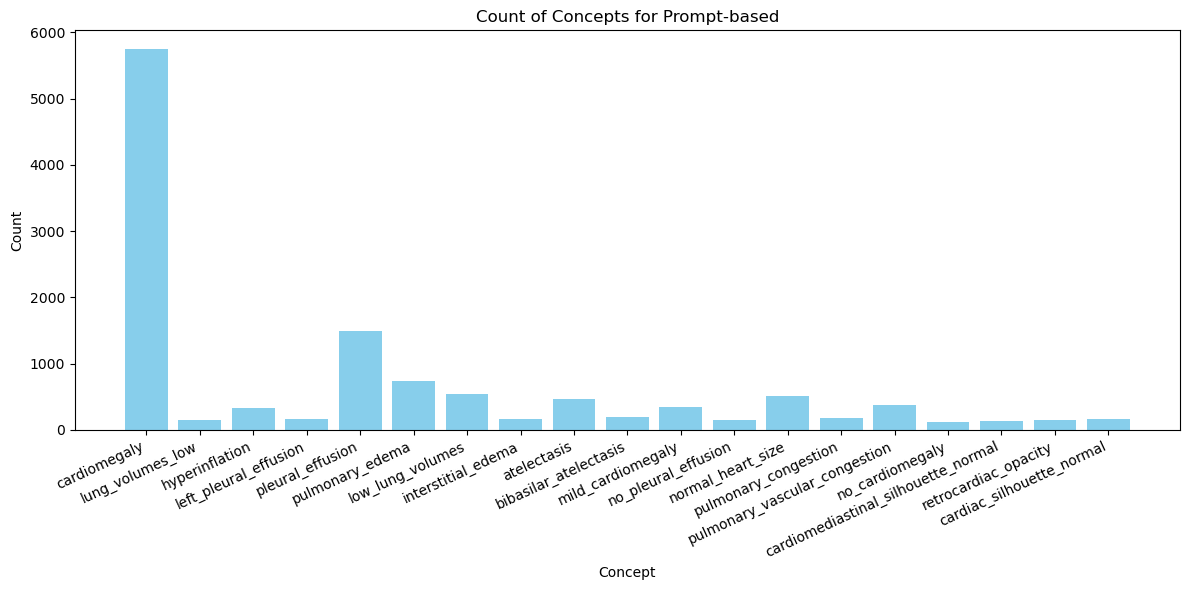

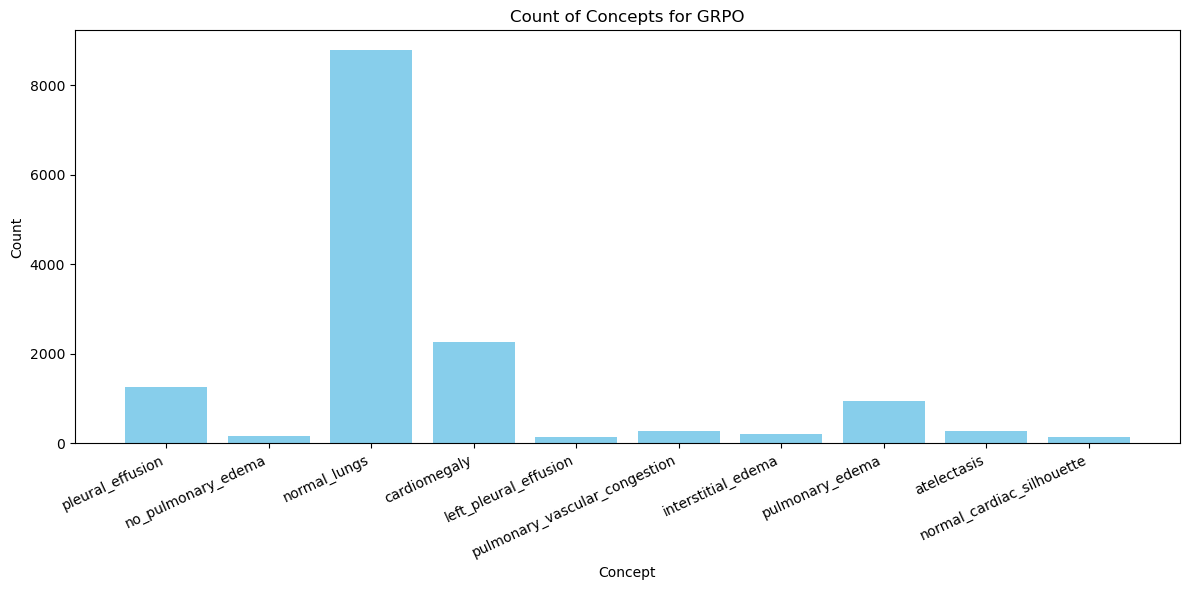

In [310]:
import matplotlib.pyplot as plt

name_map = {
    "grpo_synthetic_base": "Prompt-based",
    # "grpo_synthetic_cluster_baseline": "Prompt-based-Cluster",
    "grpo_synthetic_0": "GRPO",
    # "grpo_synthetic_cluster": "GRPO-Cluster",
    # "grpo_synthetic_cluster_56": "GRPO-Cluster (56 steps)",
}

# Draw a bar chart for topic_count for each method
for method in topic_count:
    topics = list(topic_count[method].keys())
    counts = list(topic_count[method].values())
    plt.figure(figsize=(12, 6))
    plt.bar(topics, counts, color='skyblue')
    plt.title(f"Count of Concepts for {name_map[method]}")
    plt.xlabel("Concept")
    plt.ylabel("Count")
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()


/var/folders/3h/9bh8gjqn3r99nq3frnmlnkhr0000gn/T/ipykernel_29903/147829745.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(cumulative[1:], y_pos, 'ro-', linewidth=2, markersize=6, color=color_map[method]["color"])


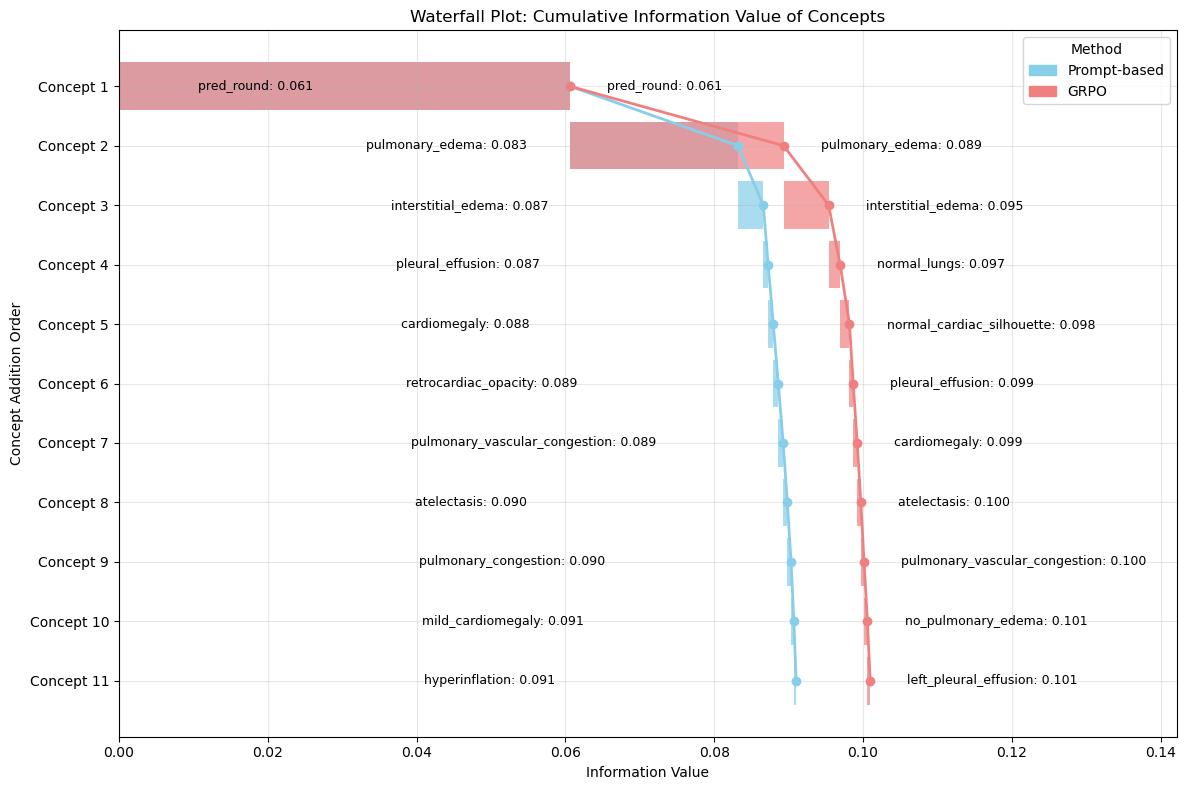

In [315]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
# Create waterfall plot for concept information values (transposed)
fig, ax = plt.subplots(figsize=(12, 8))

color_map = {
    "grpo_synthetic_base": {"color": "skyblue", "label": "Prompt-based"},
    # "grpo_synthetic_cluster_baseline": {"color": "red", "label": "Prompt-based-Cluster"},
    "grpo_synthetic_0": {"color": "lightcoral", "label": "GRPO"},
    # "grpo_synthetic_cluster": {"color": "purple", "label": "GRPO-Cluster"},
    # "grpo_synthetic_cluster_56": {"color": "green", "label": "GRPO-Cluster (56 steps)"}
}

for method in method_list:
    extst_concepts = result[method]["extst_concepts"]
    concepts_value = result[method]["concepts_value"]

    # Prepare data for waterfall plot
    y_pos = range(len(concepts_value))
    cumulative = np.cumsum([0] + concepts_value)

    # Plot bars horizontally
    for i, (concept, value) in enumerate(zip(extst_concepts, concepts_value)):
        ax.barh(i, value, left=cumulative[i], alpha=0.7, color=color_map[method]["color"])

    # Plot cumulative line
    ax.plot(cumulative[1:], y_pos, 'ro-', linewidth=2, markersize=6, color=color_map[method]["color"])

    # Add value labels on points
    for i, val in enumerate(cumulative[1:]):
        concept = extst_concepts[i].split("_", 1)[-1]
        ax.text(val + 0.005 if method == "grpo_synthetic_0" else (val + 0.05 if method == "grpo_synthetic_cluster" else val - 0.05), i, f'{concept}: {val:.3f}', ha='left', va='center', fontsize=9)

# Formatting
ax.set_ylabel('Concept Addition Order')
ax.set_xlabel('Information Value')
ax.set_xlim(0, 1 - info_model[method_list[0]].no_info_value)
ax.set_title('Waterfall Plot: Cumulative Information Value of Concepts')
ax.grid(True, alpha=0.3)

# Invert y-axis to make it start from the top
ax.invert_yaxis()

# Add legend using color_map
legend_handles = [Patch(color=color_map[method]["color"], label=color_map[method]["label"]) for method in color_map.keys()]
ax.legend(handles=legend_handles, title="Method")


plt.yticks(y_pos, [f'Concept {i+1}' for i in y_pos])
plt.tight_layout()
plt.savefig("synthetic_complementary_waterfall.png")
plt.show()


In [258]:
for method in method_list:
    if "cluster" not in method:
        continue
    print(method)
    extst_cluster = [c.split("_", 1)[-1] for c in result[method]["extst_concepts"] if c != "model_pred_round"]
    for cluster in extst_cluster:
        print(f"cluster: {cluster}, {cluster_map[method]['clusters'][cluster]}")
    # extst_cluster_name = {cluster: cluster_map[method]["clusters"][cluster] for cluster in extst_cluster}
    # print(extst_cluster_name)
    

grpo_synthetic_cluster_baseline
cluster: 92, ['liver_parenchymal_edema', 'pulmonary edema', 'pulmonary_edema_or_interstitial_lung_disease', 'bilateral_symmetric_edema', 'subclinical_edema_in_lower_extremities', 'edema_perihilar_subpleural', 'bilateral_leg_and_foot_edema_with_flattening', 'subcutaneous_edema_lower_extremities', 'hepatic_edema', 'perivascular_edema_in_pulmonary_vasculature', 'systemic_edema_no_local_localization', 'pulmonary_edema_with_attenuation', 'multi_tissue_edema', 'generalized_edema', 'lower_lobe_edema', 'subcutaneous_fatty_layer_edema', 'brain_edema', 'bilateral_pulmonary_edema_with_increased_vascular_markings', 'clinical_significance_of_cardiomegaly_and_edema', 'subcutaneous_and_intramuscular_edema', 'peripheral_edema', 'edema_in_parenchymal_and_extracellular_spaces', 'bilateral_pedal_edema', 'brain_white_matter_edema', 'diffuse_contrast-enhanced_edema', 'peripancreatic_edema', 'interstitial_and_perivascular_edema', 'edema_in_lung_zones', 'consolidation_and_inte

/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:29: FutureWarning: The provided callable <function mean at 0x1172fa340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

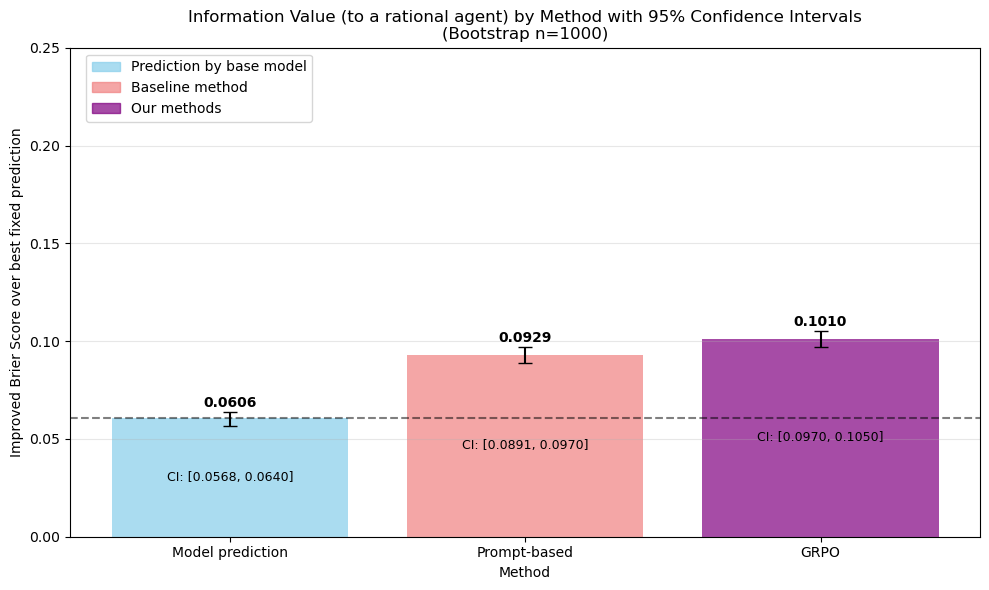

Bootstrap Analysis Summary:
Prompt-based:
  Mean: 0.092927
  95% CI: [0.089051, 0.097047]
  CI Width: 0.007996

GRPO:
  Mean: 0.100954
  95% CI: [0.097023, 0.104954]
  CI Width: 0.007931



In [ ]:
# Bootstrap analysis for all_compl_value
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Extract all_compl_value data from results
methods = list(result.keys())
method_names = ["Prompt-based", "GRPO"]  # Corresponding display names

# Prepare data for bootstrap analysis
bootstrap_results = {}
n_bootstrap = 1000

for i, method in enumerate(["model_pred_round"] + methods):
    # all_compl_value = result[method]['all_compl_value']
    if method == "model_pred_round":
        all_compl_value = info_model[methods[0]].complement_info_value(["model_pred_round"], [], ret_orig_value=True)
    else:
        all_compl_value = info_model[method].complement_info_value(concept_cols[method] + ["model_pred_round"], [], ret_orig_value=True)
    
    # Bootstrap sampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(all_compl_value, size=len(all_compl_value), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))
    
    # Calculate confidence intervals
    mean_value = np.mean(all_compl_value)
    ci_lower = np.percentile(bootstrap_means, 2.5)
    ci_upper = np.percentile(bootstrap_means, 97.5)
    
    bootstrap_results[method] = {
        'mean': mean_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'bootstrap_means': bootstrap_means
    }

# Create bar chart with confidence intervals
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(methods) + 1)
means = [bootstrap_results[method]['mean'] for method in ["model_pred_round"] + methods]
ci_lowers = [bootstrap_results[method]['ci_lower'] for method in ["model_pred_round"] + methods]
ci_uppers = [bootstrap_results[method]['ci_upper'] for method in ["model_pred_round"] + methods]

# Calculate error bars
yerr_lower = [means[i] - ci_lowers[i] for i in range(len(means))]
yerr_upper = [ci_uppers[i] - means[i] for i in range(len(means))]

# Create bars with error bars
bars = ax.bar(x_pos, means, yerr=[yerr_lower, yerr_upper], 
              capsize=5, alpha=0.7, 
              color=['skyblue', 'lightcoral', 'purple', 'purple'])

# Add value labels on bars
for i, (bar, mean_val, ci_low, ci_up) in enumerate(zip(bars, means, ci_lowers, ci_uppers)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (ci_up - mean_val) + 0.001,
            f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            f'CI: [{ci_low:.4f}, {ci_up:.4f}]', ha='center', va='center', 
            fontsize=9, rotation=0)

# Formatting
ax.set_xlabel('Method')
ax.set_ylabel('Improved Brier Score over best fixed prediction')
ax.set_ylim(0.0, 0.25)
ax.set_title('Information Value (to a rational agent) by Method with 95% Confidence Intervals\n(Bootstrap n=1000)')
ax.set_xticks(x_pos)
ax.set_xticklabels(["Model prediction"] + method_names)
ax.grid(True, alpha=0.3, axis='y')

# Add horizontal line at y=0 for reference
ax.axhline(y=bootstrap_results["model_pred_round"]["mean"], color='black', linestyle='--', alpha=0.5)

legend_labels = ['Prediction by base model', 'Baseline method', 'Our methods']
legend_colors = ['skyblue', 'lightcoral', 'purple']

# Create legend handles
legend_handles = [plt.Rectangle((0,0),1,1, color=color, alpha=0.7) for color in legend_colors[:(len(methods) + 1)]]
legend_labels_filtered = legend_labels[:len(methods) + 1]
# Add legend to the last subplot
ax.legend(legend_handles, legend_labels_filtered, loc='upper left', bbox_to_anchor=(0.01, 1))

plt.tight_layout()
plt.savefig("synthetic_complementary_rational_agent.png")
plt.show()

# Print summary statistics
print("Bootstrap Analysis Summary:")
print("=" * 50)
for i, method in enumerate(methods):
    stats_dict = bootstrap_results[method]
    print(f"{method_names[i]}:")
    print(f"  Mean: {stats_dict['mean']:.6f}")
    print(f"  95% CI: [{stats_dict['ci_lower']:.6f}, {stats_dict['ci_upper']:.6f}]")
    print(f"  CI Width: {stats_dict['ci_upper'] - stats_dict['ci_lower']:.6f}")
    print()


In [297]:
# method_list = ["topicgpt_0", "dspy_0","dpo_0",  "grpo_0", "dspy_1"]

import xgboost as xgb
from sklearn.linear_model import LogisticRegression

train_data = data.sample(frac=0.7, random_state=42)
test_data = data.drop(train_data.index)

def train_logistic_regression(train_concept_data, method_id, concept_cols):
    logistic_regression = LogisticRegression(random_state=42, max_iter=1000)
    logistic_regression.fit(train_concept_data[concept_cols], train_concept_data["abnormal_stratified"])
    return logistic_regression

def train_xgboost(train_concept_data, method_id, concept_cols):
    xgboost = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=20,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    )
    xgboost.fit(train_concept_data[concept_cols], train_concept_data["abnormal_stratified"])
    return xgboost

use_model = "xgboost" # "logistic_regression"

for method in method_list:
    train_xgb_data = merged_data[method].loc[train_data.index, :]
    test_xgb_data = merged_data[method].drop(train_data.index)

    if use_model == "xgboost":
        xgboost = train_xgboost(train_xgb_data, method, concept_cols[method] + ["model_pred_round"])
        train_prediction = xgboost.predict_proba(train_xgb_data[concept_cols[method] + ["model_pred_round"]])[:, 1]
        train_data[f"{method}_pred"] = train_prediction
        # Print XGBoost feature importance (coefficients)
        feature_names = concept_cols[method] + ["model_pred_round"]
        feature_importance = xgboost.feature_importances_
        print(f"\n{method} XGBoost Feature Importance:")
        for name, importance in zip(feature_names, feature_importance):
            print(f"  {name}: {importance:.4f}")
        train_brier_score = np.mean(1 - (train_prediction - train_xgb_data["abnormal_stratified"]) ** 2)
        print(f"{method} Train Brier Score: {train_brier_score}")
        test_data[f"{method}_pred"] = xgboost.predict_proba(test_xgb_data[concept_cols[method] + ["model_pred_round"]])[:, 1]
        test_brier_score = np.mean(1 - (test_data[f"{method}_pred"] - test_data["abnormal_stratified"]) ** 2)
        print(f"{method} Test Brier Score: {test_brier_score}")
    elif use_model == "logistic_regression":
        logistic_regression = train_logistic_regression(train_xgb_data, method, concept_cols[method] + ["model_pred_round"])
        train_prediction = logistic_regression.predict_proba(train_xgb_data[concept_cols[method] + ["model_pred_round"]])[:, 1]
        train_data[f"{method}_pred"] = train_prediction
        test_data[f"{method}_pred"] = logistic_regression.predict_proba(test_xgb_data[concept_cols[method] + ["model_pred_round"]])[:, 1]
        train_brier_score = np.mean(1 - (train_prediction - train_xgb_data["abnormal_stratified"]) ** 2)
        print(f"{method} Train Brier Score: {train_brier_score}")
        test_brier_score = np.mean(1 - (test_data[f"{method}_pred"] - test_data["abnormal_stratified"]) ** 2)
        print(f"{method} Test Brier Score: {test_brier_score}")


grpo_synthetic_base XGBoost Feature Importance:
  concepts_atelectasis: 0.0055
  concepts_bibasilar_atelectasis: 0.0048
  concepts_cardiac_silhouette_normal: 0.0055
  concepts_cardiomediastinal_silhouette_normal: 0.0081
  concepts_cardiomegaly: 0.0038
  concepts_hyperinflation: 0.0058
  concepts_interstitial_edema: 0.0813
  concepts_left_pleural_effusion: 0.0014
  concepts_low_lung_volumes: 0.0030
  concepts_lung_volumes_low: 0.0030
  concepts_mild_cardiomegaly: 0.0064
  concepts_no_cardiomegaly: 0.0056
  concepts_no_pleural_effusion: 0.0012
  concepts_normal_heart_size: 0.0096
  concepts_pleural_effusion: 0.0045
  concepts_pulmonary_congestion: 0.0083
  concepts_pulmonary_edema: 0.6654
  concepts_pulmonary_vascular_congestion: 0.0041
  concepts_retrocardiac_opacity: 0.0131
  model_pred_round: 0.1596
grpo_synthetic_base Train Brier Score: 0.9488744139671326
grpo_synthetic_base Test Brier Score: 0.9444600939750671

grpo_synthetic_0 XGBoost Feature Importance:
  concepts_atelectasis: 0.

In [151]:
test_data

,report,seed,abnormal_stratified,model_pred,filtered_seed,grpo_synthetic_baseline_concepts,grpo_synthetic2_concepts,model_pred_round,grpo_synthetic_baseline_pred,grpo_synthetic2_pred
1,The chest radiograph demonstrates a focal area...,['Atelectasis'],False,0.072646,[],"[{'name': 'atelectasis', 'description': 'Focal...","[{'name': 'pulmonary_atelectasis', 'descriptio...",0.072646,0.013724,0.004304
2,A thoracic computed tomography (CT) scan of th...,"['Lung Opacity', 'Pleural Effusion']",True,0.815321,[],"[{'name': 'bilateral_pulmonary_opacities', 'de...","[{'name': 'pulmonary_opacities', 'description'...",0.815321,0.998918,0.999051
3,The chest radiograph demonstrates a moderate d...,"['Atelectasis', 'Cardiomegaly']",False,0.257716,[],"[{'name': 'right_lower_lobe_atelectasis', 'des...","[{'name': 'right_lower_lobe_atelectasis', 'des...",0.257716,0.013447,0.058416
4,Echocardiographic evaluation reveals significa...,['Cardiomegaly'],False,0.347237,[],"[{'name': 'left_ventricular_enlargement', 'des...","[{'name': 'left_ventricular_dilation', 'descri...",0.347237,0.055912,0.059188
5,The imaging findings reveal evidence of diffus...,['Edema'],True,0.107162,['Edema'],"[{'name': 'diffuse_parenchymal_edema', 'descri...","[{'name': 'diffuse_parenchymal_edema', 'descri...",0.107162,0.903261,0.938575
...,...,...,...,...,...,...,...,...,...,...
7980,A chest radiograph was obtained for a patient ...,['Pneumonia'],False,0.180918,[],[],"[{'name': 'right_lower_lobe_consolidation', 'd...",0.180918,0.099772,0.122192
7982,The chest radiograph demonstrates bilateral lo...,"['Consolidation', 'Pleural Effusion']",True,0.625795,['Consolidation'],"[{'name': 'pulmonary_consolidation', 'descript...","[{'name': 'pulmonary_consolidation', 'descript...",0.625795,0.123244,0.022163
7984,The chest radiograph demonstrates a mild right...,"['Atelectasis', 'Lung Lesion', 'Lung Opacity']",False,0.089999,[],"[{'name': 'right_lower_lobe_atelectasis', 'des...","[{'name': 'right_lower_lobe_atelectasis', 'des...",0.089999,0.015696,0.014932
7988,The imaging findings reveal evidence of genera...,['Edema'],True,0.107162,['Edema'],[{'name': 'generalized_soft_tissue_edema_lower...,"[{'name': 'lower_extremity_edema', 'descriptio...",0.107162,0.903261,0.938575


In [301]:
from scipy.stats import bootstrap

def brier_score(pred_proba, label):
    return 1 - (pred_proba - label) ** 2

def threshold_accuracy(pred_proba, label):
    return (pred_proba > 0.5).astype(int) == label


def score_FP_FN(pred_proba, label, l=0.5):
    threshold = l / (1 + l)
    return (pred_proba > threshold).astype(int) == label

def calibration_error(pred_proba, label):
    temp_df = pd.DataFrame({"pred_proba": np.round(pred_proba, 2), "label": label})
    temp_df_group = temp_df.groupby("pred_proba").agg({"label": "mean"}).reset_index()
    temp_df = pd.merge(temp_df, temp_df_group, on="pred_proba", how="left")
    return np.abs(temp_df["pred_proba"] - temp_df["label_y"])

def multicalibration_error(pred_proba, signals, label):
    temp_df = pd.DataFrame({"pred_proba": pred_proba, "signals": signals, "label": label})
    temp_df.loc[:, "signals"] = temp_df["signals"].apply(lambda x: eval(x))
    temp_df.loc[:, "signals"] = temp_df["signals"].apply(lambda x: [t["name"] if isinstance(t, dict) else t for t in x])
    temp_df.loc[:, "signals"] = temp_df["signals"].apply(lambda x: str(x))
    temp_df_group = temp_df.groupby(["pred_proba", "signals"]).agg({"label": "mean"}).reset_index()
    temp_df = pd.merge(temp_df, temp_df_group, on=["pred_proba", "signals"], how="left")
    return np.abs(temp_df["pred_proba"] - temp_df["label_y"])


# Calculate all metrics for each method
methods = ['Model prediction','Model prediction +\n No RL signals', 'Model prediction +\n GRPO signals']
diagnosis_cols = ['model_pred_round'] + [f"{method}_pred" for method in method_list]
# concept_cols = [None, 'dpo_0_concepts', 'dspy_0_concepts', 'grpo_0_concepts']

# Calculate metrics
brier_scores = []
accuracies = []
FP_FN_05_scores = []
FP_FN_02_scores = []
FP_FN_2_scores = []
FP_FN_5_scores = []

for diag_col in diagnosis_cols:
    # Brier score
    brier = brier_score(test_data[diag_col], test_data["abnormal_stratified"].astype(int))
    # print(brier)
    # brier = np.array([s > 0.9 for s in brier])

    brier_scores.append(bootstrap((brier,), np.mean, confidence_level=0.95, random_state=42))
    
    # Accuracy
    acc = threshold_accuracy(test_data[diag_col], test_data["abnormal_stratified"].astype(int))
    accuracies.append(bootstrap((acc,), np.mean, confidence_level=0.95, random_state=42))


    # 0.5 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=0.5)
    FP_FN_05_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    # 0.2 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=0.2)
    FP_FN_02_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    # 2 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=2)
    FP_FN_2_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    # 5 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=5)
    FP_FN_5_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))

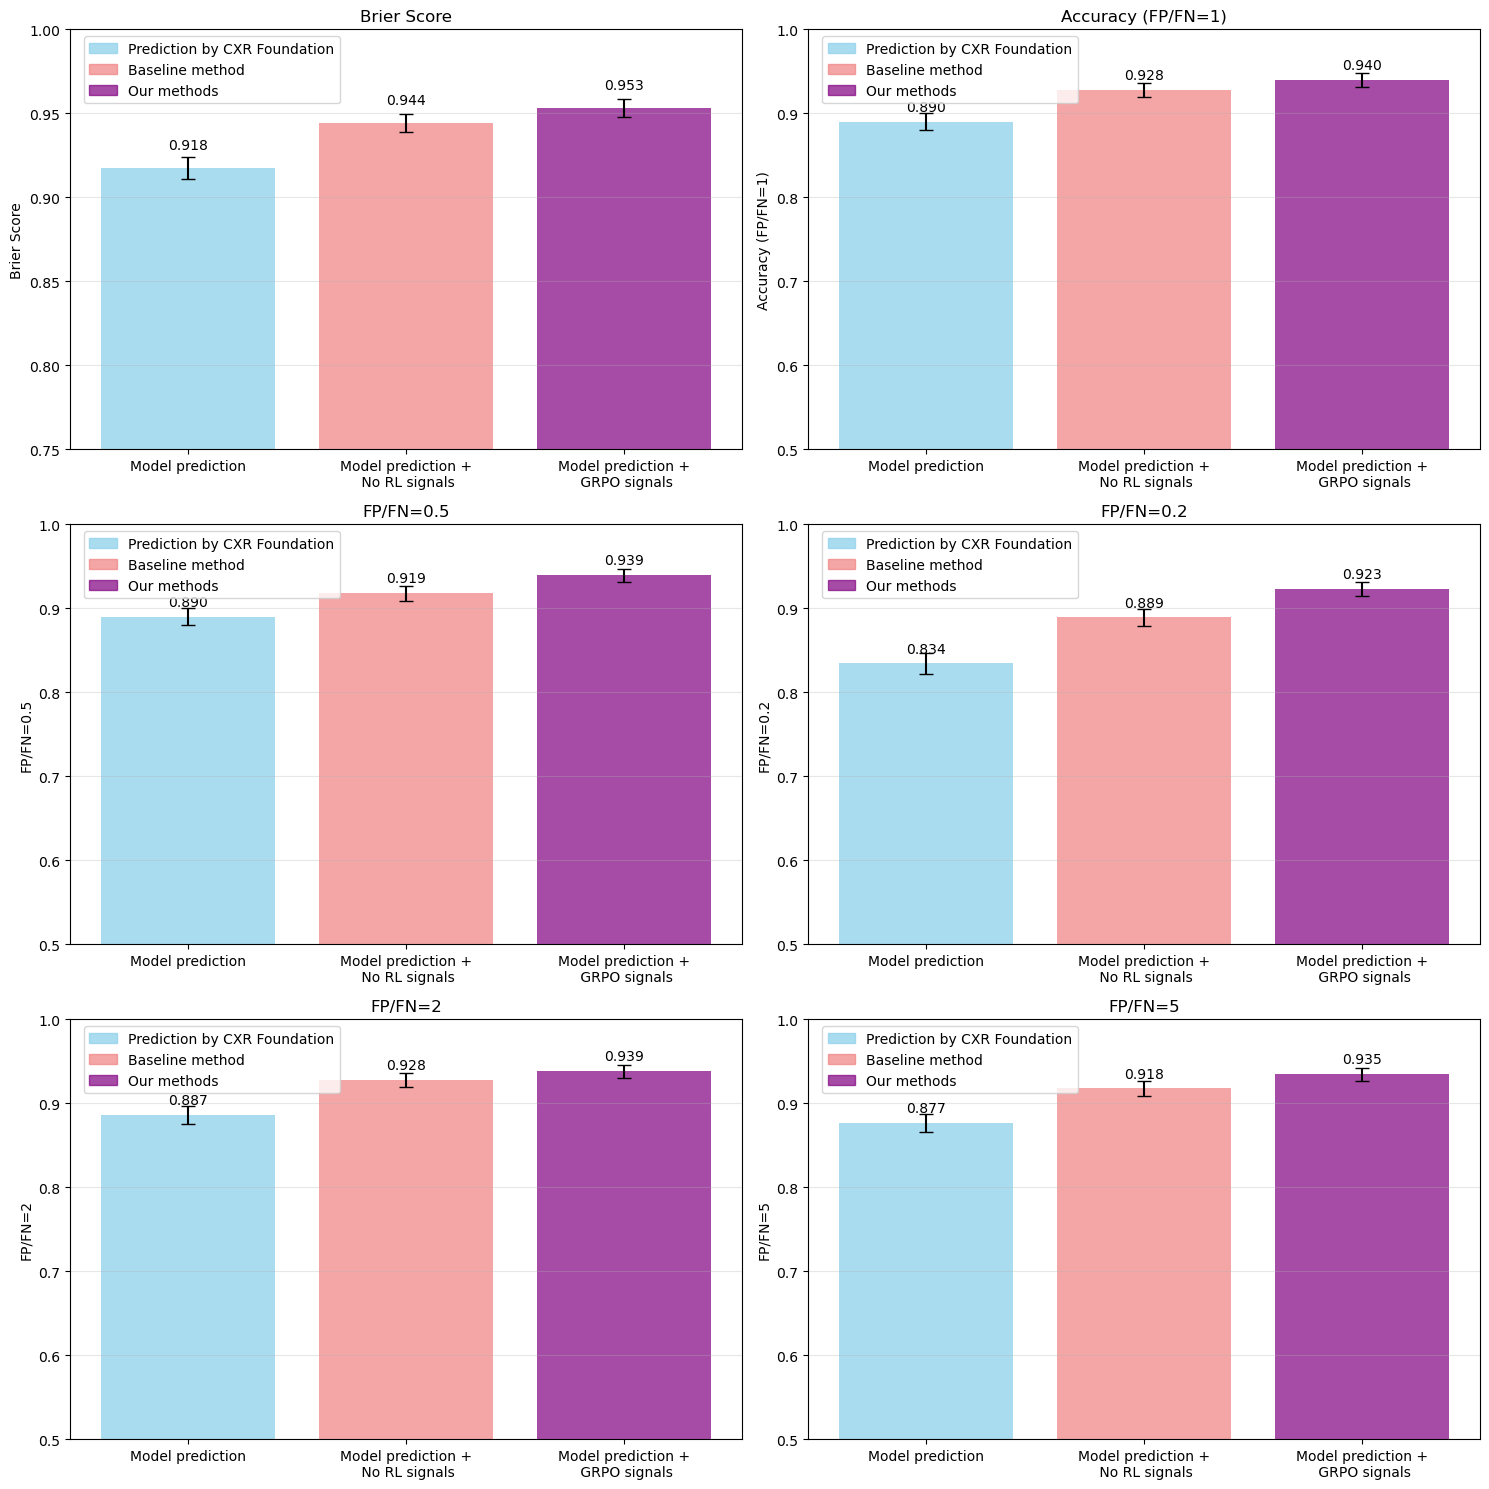

In [302]:

metrics = [
    ('Brier Score', brier_scores, 'skyblue'),
    ('Accuracy (FP/FN=1)', accuracies, 'lightcoral'),
    ('FP/FN=0.5', FP_FN_05_scores, 'purple'),
    ('FP/FN=0.2', FP_FN_02_scores, 'purple'),
    ('FP/FN=2', FP_FN_2_scores, 'purple'),
    ('FP/FN=5', FP_FN_5_scores, 'purple'),
    # ('Calibration Error', calibration_errors, 'lightgreen'),
    # ('Multicalibration Error', multicalibration_errors, 'gold')
]

# Create subplot with 4 metrics
fig, axes = plt.subplots(len(metrics)//2, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (metric_name, values, color) in enumerate(metrics):
    ax = axes[i]
    colors = ['skyblue','lightcoral', 'purple', 'purple']
    bars = ax.bar(methods, [np.mean(v.bootstrap_distribution) for v in values], alpha=0.7, 
                  color=colors[:len(methods)], capsize=5, 
                  yerr=([np.mean(v.bootstrap_distribution) - v.confidence_interval.low for v in values], [v.confidence_interval.high - np.mean(v.bootstrap_distribution) for v in values]))
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if metric_name == 'Accuracy (Threshold=0.5)':
            ax.text(bar.get_x() + bar.get_width()/2., height + max([np.mean(v.bootstrap_distribution) for v in values]) * 0.01,
                    f'{np.mean(value.bootstrap_distribution):.1%}', ha='center', va='bottom', fontsize=10)
        else:
            ax.text(bar.get_x() + bar.get_width()/2., height + max([np.mean(v.bootstrap_distribution) for v in values]) * 0.01,
                    f'{np.mean(value.bootstrap_distribution):.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel(metric_name)
    # ax.set_xlabel('Method')
    ax.set_title(f'{metric_name}')
    ax.grid(True, alpha=0.3, axis='y')
    # Set y-axis to percentage
    if metric_name == 'Accuracy (Threshold=0.5)':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    if metric_name == 'Brier Score':
        ax.set_ylim(0.75, 1)
    else:
        ax.set_ylim(0.5, 1)
    
    # Add legend for the colors
    legend_labels = ['Prediction by CXR Foundation', 'Baseline method', 'Our methods']
    legend_colors = ['skyblue', 'lightcoral', 'purple']
    
    # Create legend handles
    legend_handles = [plt.Rectangle((0,0),1,1, color=color, alpha=0.7) for color in legend_colors[:len(methods)]]
    legend_labels_filtered = legend_labels[:len(methods)]
    
    # Add legend to the last subplot
    ax.legend(legend_handles, legend_labels_filtered, loc='upper left', bbox_to_anchor=(0.01, 1))
    # axes[1].legend(legend_handles, legend_labels_filtered, loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("synthetic_complementary_signals.png")
plt.show()

In [134]:
test_data

,report,seed,abnormal_stratified,model_pred,filtered_seed,grpo_synthetic_baseline_concepts,grpo_synthetic_concepts,model_pred_round,grpo_synthetic_baseline_pred,grpo_synthetic_pred
1,The chest radiograph demonstrates a focal area...,['Atelectasis'],False,0.072646,[],"[{'name': 'atelectasis', 'description': 'Focal...","[{'name': 'atelectasis', 'description': 'Focal...",0.072646,0.016818,0.001972
2,A thoracic computed tomography (CT) scan of th...,"['Lung Opacity', 'Pleural Effusion']",True,0.815321,[],"[{'name': 'bilateral_pulmonary_opacities', 'de...","[{'name': 'bilateral_pulmonary_opacities', 'de...",0.815321,0.999182,0.999088
3,The chest radiograph demonstrates a moderate d...,"['Atelectasis', 'Cardiomegaly']",False,0.257716,[],"[{'name': 'right_lower_lobe_atelectasis', 'des...","[{'name': 'right_lower_lobe_atelectasis', 'des...",0.257716,0.029214,0.108221
4,Echocardiographic evaluation reveals significa...,['Cardiomegaly'],False,0.347237,[],"[{'name': 'left_ventricular_enlargement', 'des...","[{'name': 'cardiomegaly', 'description': 'Sign...",0.347237,0.206762,0.149200
5,The imaging findings reveal evidence of diffus...,['Edema'],True,0.107162,['Edema'],"[{'name': 'diffuse_parenchymal_edema', 'descri...","[{'name': 'diffuse_parenchymal_edema', 'descri...",0.107162,0.962734,0.987045
...,...,...,...,...,...,...,...,...,...,...
7980,A chest radiograph was obtained for a patient ...,['Pneumonia'],False,0.180918,[],[],"[{'name': 'right_lower_lobe_consolidation', 'd...",0.180918,0.086555,0.075065
7982,The chest radiograph demonstrates bilateral lo...,"['Consolidation', 'Pleural Effusion']",True,0.625795,['Consolidation'],"[{'name': 'pulmonary_consolidation', 'descript...","[{'name': 'pulmonary_consolidation', 'descript...",0.625795,0.972806,0.980891
7984,The chest radiograph demonstrates a mild right...,"['Atelectasis', 'Lung Lesion', 'Lung Opacity']",False,0.089999,[],"[{'name': 'right_lower_lobe_atelectasis', 'des...","[{'name': 'right_lower_lobe_atelectasis', 'des...",0.089999,0.049250,0.038868
7988,The imaging findings reveal evidence of genera...,['Edema'],True,0.107162,['Edema'],[{'name': 'generalized_soft_tissue_edema_lower...,[{'name': 'soft_tissue_edema_lower_extremities...,0.107162,0.962734,0.987045


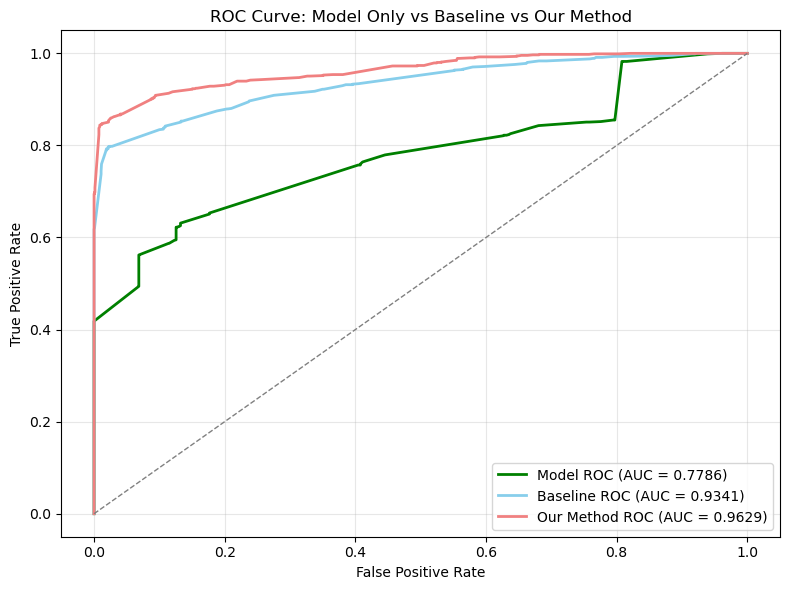

In [156]:
from sklearn.metrics import roc_auc_score
# Compute ROC curve and AUC for both baseline and our method
fpr_baseline, tpr_baseline, _ = roc_curve(test_data["abnormal_stratified"].astype(int), test_data["grpo_synthetic_baseline_pred"])
auc_baseline = roc_auc_score(test_data["abnormal_stratified"].astype(int), test_data["grpo_synthetic_baseline_pred"])

fpr_ours, tpr_ours, _ = roc_curve(test_data["abnormal_stratified"].astype(int), test_data["grpo_synthetic2_pred"])
auc_ours = roc_auc_score(test_data["abnormal_stratified"].astype(int), test_data["grpo_synthetic2_pred"])

fpr_model, tpr_model, _ = roc_curve(test_data["abnormal_stratified"].astype(int), test_data["model_pred_round"])
auc_model = roc_auc_score(test_data["abnormal_stratified"].astype(int), test_data["model_pred_round"])

plt.figure(figsize=(8,6))
plt.plot(fpr_model, tpr_model, color="green", lw=2, label=f'Model ROC (AUC = {auc_model:.4f})')
plt.plot(fpr_baseline, tpr_baseline, color=color_map["grpo_synthetic_baseline"]["color"], lw=2, label=f'Baseline ROC (AUC = {auc_baseline:.4f})')
plt.plot(fpr_ours, tpr_ours, color=color_map["grpo_synthetic2"]["color"], lw=2, label=f'Our Method ROC (AUC = {auc_ours:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Model Only vs Baseline vs Our Method')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("synthetic_complementary_signals_roc.png")
plt.show()
